In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
from scipy.ndimage import gaussian_filter1d
import tensorflow as tf

In [2]:
plt.rcParams.update({
    "text.usetex": False,           
    "font.family": "sans-serif",
    "font.sans-serif": ["Tahoma"]
})

In [ ]:
def plot_bars_performance(tpn_means, tpn_std, sincnet_means, sincnet_std):
    
    groups = ['Linear Evaluation', 'Fine-Tuned Evaluation']
    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Create Grouped Bars
    rects1 = ax.bar(x - width/2, tpn_means, width, yerr=tpn_std, label='TPN', 
                    capsize=10, color="#ffc845", alpha=0.8, edgecolor='black')
    rects2 = ax.bar(x + width/2, sincnet_means, width, yerr=sincnet_std, label='SincTPN', 
                    capsize=10, color='#1b365d', alpha=0.8, edgecolor='black')

    # 2. Formatting & Font Sizes
    ax.set_ylabel('Weighted F1 Score', fontsize=20)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0.5, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # 3. Add Legend
    ax.legend(fontsize=14, loc='upper right')

    # 4. Helper function for labels
    def autolabel(rects, stds):
        for i, rect in enumerate(rects):
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height + stds[i] + 0.01),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=20, fontweight='bold')

    autolabel(rects1, tpn_std)
    autolabel(rects2, sincnet_std)

    plt.tight_layout()
    plt.show()

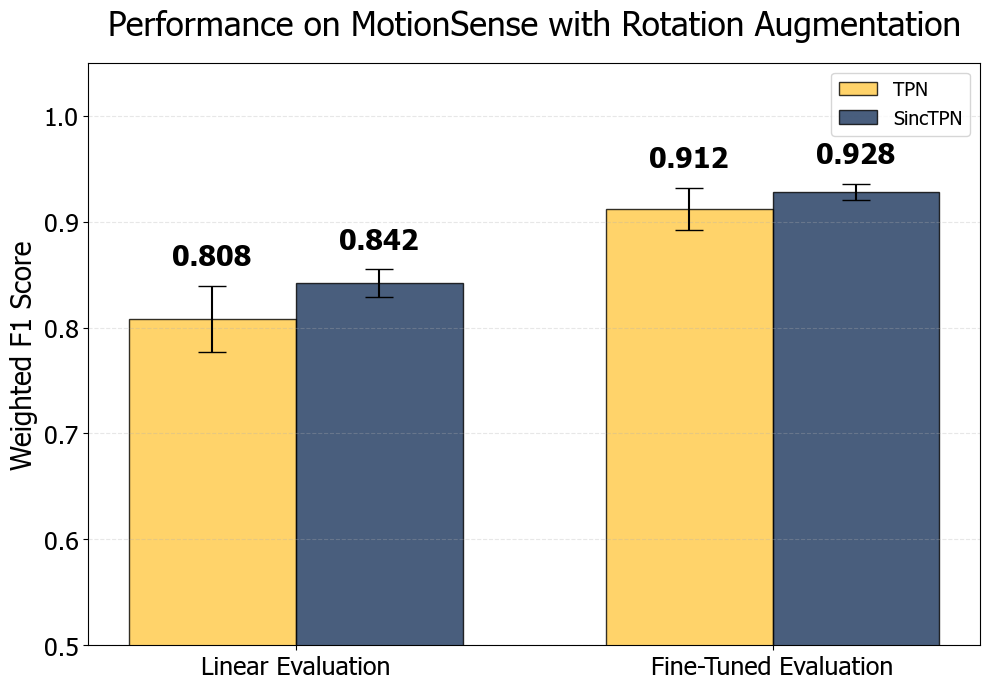

In [ ]:
# MotionSense Rotation
plot_bars_performance(
    tpn_means=[0.808, 0.912],
    tpn_std=[0.031, 0.020],
    sincnet_means=[0.842, 0.928],
    sincnet_std=[0.013, 0.008]
)

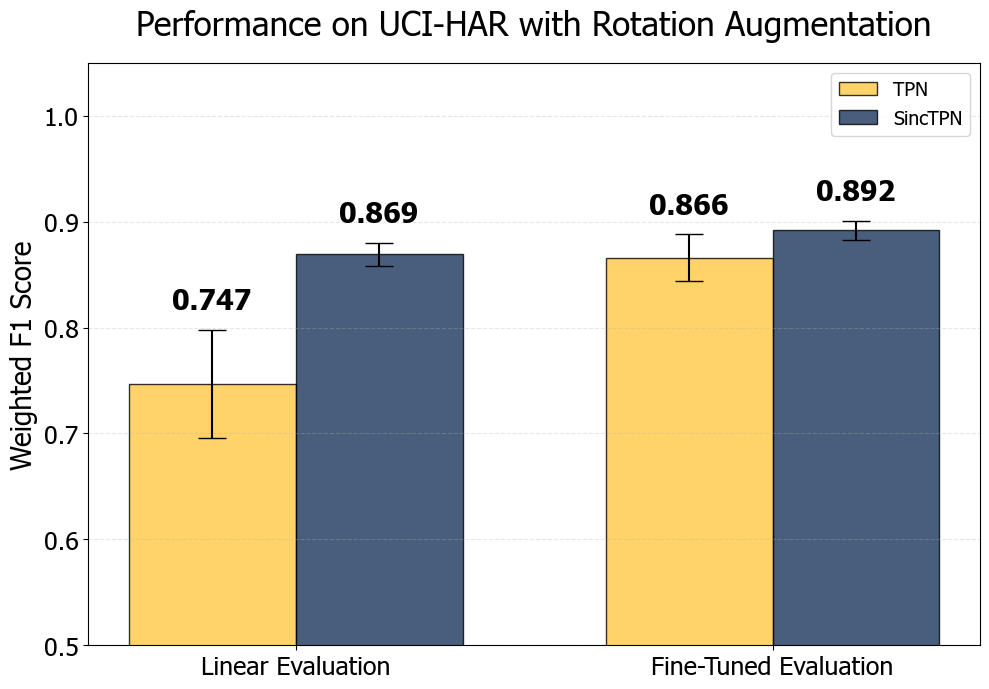

In [ ]:
# UCI-HAR Rotation
plot_bars_performance(
    tpn_means=[0.747, 0.866],
    tpn_std=[0.051, 0.022],
    sincnet_means=[0.869, 0.892],
    sincnet_std=[0.011, 0.009]
)

In [3]:
def get_sincconv_layer(model, layer_name="sincconv"):
    for layer in model.layers:
        if layer.name == layer_name:
            return layer
    # recurse into sub-models
    for layer in model.layers:
        if hasattr(layer, "layers"):
            result = get_sincconv_layer(layer, layer_name)
            if result is not None:
                return result
    return None

In [30]:
def compute_aggregate_response(sincconv_layer, n_freqs=1024, smooth_sigma=20):
    """
    Reconstruct every filter's frequency response from learned f1 / band
    weights, sum them, apply Gaussian smoothing, and normalise to [0, 1].

    Works for both depthwise=True  (f1_ shape: [C, num_filters])
               and depthwise=False (f1_ shape: [num_filters]).

    Parameters
    ----------
    n_freqs      : int    frequency resolution
    smooth_sigma : float  Gaussian sigma in frequency bins; increase for
                          smoother curves (try 12–25 for paper figures)

    Returns
    -------
    freqs_norm : np.ndarray  (n_freqs,)  normalised frequency [0, 1]
    response   : np.ndarray  (n_freqs,)  smoothed, normalised response
    """
    layer    = sincconv_layer
    nyquist  = layer.sample_rate / 2.0
    min_low  = layer.min_low_hz  / nyquist
    min_band = layer.min_band_hz / nyquist

    f1_w   = layer.f1_.numpy()
    band_w = layer.band_.numpy()

    if f1_w.ndim == 2:          # depthwise: (C, F) → (C*F,)
        f1_w   = f1_w.reshape(-1)
        band_w = band_w.reshape(-1)

    f1 = np.abs(f1_w)   + min_low
    f2 = np.clip(f1 + np.abs(band_w) + min_band, 0.0, 1.0)

    freqs_norm = np.linspace(0.0, 1.0, n_freqs)

    # Rectangular bandpass indicator, summed across all filters
    response = np.zeros(n_freqs)
    for lo, hi in zip(f1, f2):
        response += (freqs_norm >= lo) & (freqs_norm <= hi)

    # Gaussian smoothing — much cleaner than uniform_filter for paper figures
    response = gaussian_filter1d(response.astype(float), sigma=smooth_sigma)

    if response.max() > 0:
        response /= response.max()

    return freqs_norm, response

In [45]:
def plot_filter_responses(
    models,
    dataset_names,
    augmentation_names=None,
    layer_name="sincconv",
    colors=None,
    smooth_sigma=20,
    save_path=None,
):
    """
    Parameters
    ----------
    models            : dict  {aug_name: [model_ds0, model_ds1, model_ds2]}
    dataset_names     : list of str
    augmentation_names: list of str or None  (uses dict keys if None)
    layer_name        : str
    colors            : list of str or None  (one per dataset)
    smooth_sigma      : float  Gaussian smoothing strength (bins); tune to taste
    save_path         : str or None  e.g. "sincnet_filters.pdf"
    """
    aug_names = augmentation_names or list(models.keys())
    n_augs    = len(aug_names)
    n_ds      = len(dataset_names)

    # ── Style ────────────────────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family":       "sans-serif",
        "font.sans-serif": ["Tahoma"],
        "font.size":         13,
        "axes.titlesize":    15,
        "axes.labelsize":    13,
        "xtick.labelsize":   12,
        "ytick.labelsize":   12,
        "axes.linewidth":    1.2,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "lines.linewidth":   2.5,
        "legend.fontsize":   13,
        "legend.frameon":    False,
    })

    if colors is None:
        # Wong (2011) colorblind-safe palette
        colors = ["#E69F00", "#56A2E9", "#459E00"][:n_ds]
 
    # Two-column paper width (~7 in)
    figsize = (12.0, 4.0)
 
    fig, axes = plt.subplots(1, n_augs, figsize=figsize, sharey=True)
    if n_augs == 1:
        axes = [axes]
 
    for ax, aug in zip(axes, aug_names):
        for ds_idx, (ds_name, model) in enumerate(
            zip(dataset_names, models[aug])
        ):
            sincconv = get_sincconv_layer(model, layer_name)
            if sincconv is None:
                raise ValueError(
                    f"No layer '{layer_name}' found for aug='{aug}', "
                    f"dataset='{ds_name}'."
                )
 
            freqs, resp = compute_aggregate_response(
                sincconv, smooth_sigma=smooth_sigma
            )
 
            ax.plot(freqs, resp, color=colors[ds_idx], label=ds_name)
 
        # ── Panel formatting ─────────────────────────────────────────────────
        ax.set_title(aug, fontweight="bold", pad=5)
        ax.set_xlabel("Frequency\n(Fraction of Nyquist)")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.09)
 
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.25))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
 
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.25))
 
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(which="both", direction="out")
        ax.tick_params(which="minor", length=2)
 
        ax.grid(axis="x", which="major", linestyle=":", linewidth=0.4,
                color="gray", alpha=0.4)
 
    axes[0].set_ylabel("Normalized Frequency Response\n(Aggregated Across Channels)")
 
    # ── Legend below figure, horizontally centered ────────────────────────────
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=n_ds,
        bbox_to_anchor=(0.5, -0.18),
        handlelength=1.5,
        handletextpad=0.5,
        columnspacing=1.2,
    )
 
    fig.tight_layout(pad=0.5)
    fig.subplots_adjust(bottom=0.12)  # room for legend
 
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")
 
    return fig

In [32]:
rot_paths = ["ms_rotation_simclr.keras", "uci_rotation_simclr.keras", "cp24_rotation_simclr.keras"]
noise_paths = ["ms_j_simclr.keras", "uci_jittering_simclr.keras", "cp24_jittering_simclr.keras"]
warp_paths = ["ms_w_simclr.keras", "uci_timewarp_simclr.keras", "cp24_timewarp_simclr.keras"]

Saved to filters.png


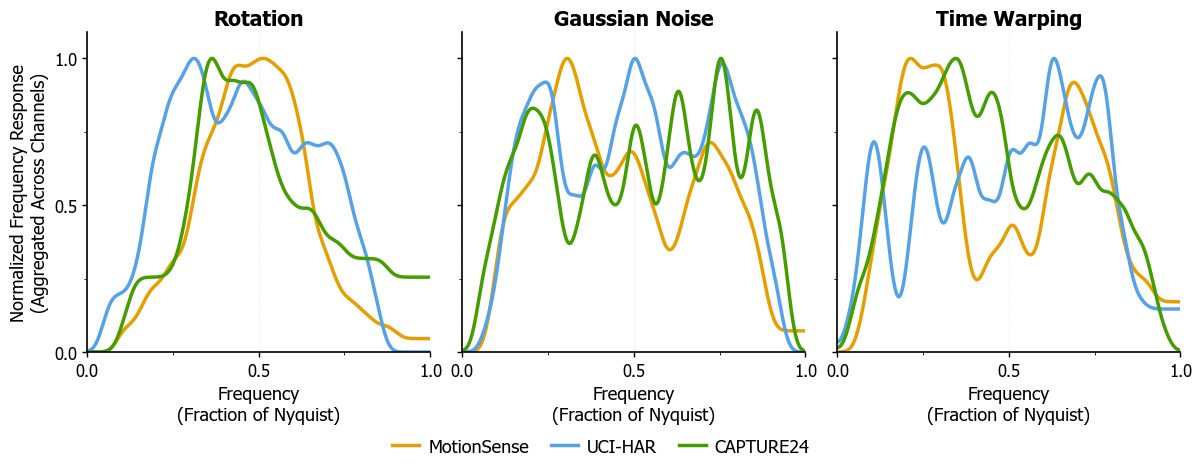

In [46]:
import simclr_models
models = {
    "Rotation":   [tf.keras.models.load_model(p, custom_objects={'SincConv1D': simclr_models.SincConv1D}) for p in rot_paths],
    "Gaussian Noise":      [tf.keras.models.load_model(p, custom_objects={'SincConv1D': simclr_models.SincConv1D}) for p in noise_paths],
    "Time Warping":  [tf.keras.models.load_model(p, custom_objects={'SincConv1D': simclr_models.SincConv1D}) for p in warp_paths],}
dataset_names = ["MotionSense", "UCI-HAR", "CAPTURE24"]
fig = plot_filter_responses(models, dataset_names, save_path="filters.png")
plt.show()